In [1]:
import importlib_resources
import numpy as np
import xlrd
import pandas as pd
from scipy.linalg import svd 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [32]:
# Load csv file with data
df = pd.read_csv('null-corrected.csv')

In [33]:
df.head()

,index,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [34]:
df['chol'] = np.log(df['chol'])
df.head()

,index,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0,63.0,1.0,1.0,145.0,5.451038,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,1,67.0,1.0,4.0,160.0,5.655992,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,2,67.0,1.0,4.0,120.0,5.433722,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,3,37.0,1.0,3.0,130.0,5.521461,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,4,41.0,0.0,2.0,130.0,5.318120,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [35]:
# Extract attribute names
attributeNames = df.columns[1:15].tolist()
print(attributeNames)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [36]:
# Konverter til et numpy-array (dog uden index-kolonne samt target-kolonne) 
X = df.iloc[:, 1:-1].to_numpy()
X

array([[63.,  1.,  1., ...,  3.,  0.,  6.],
       [67.,  1.,  4., ...,  2.,  3.,  3.],
       [67.,  1.,  4., ...,  2.,  2.,  7.],
       ...,
       [57.,  1.,  4., ...,  2.,  1.,  7.],
       [57.,  0.,  2., ...,  2.,  1.,  3.],
       [38.,  1.,  3., ...,  1.,  0.,  3.]], shape=(303, 13))

In [37]:
# Standardisering af data - træk middelværdi fra og divider med standardafvigelse
N = len(X)
X_ = X - np.ones((N, 1)) * X.mean(axis=0)
X_hat = X_ / X.std(axis=0)
X_hat

array([[ 0.94872647,  0.68620244, -2.25177456, ...,  2.27457861,
        -0.71113139,  0.65913253],
       [ 1.39200191,  0.68620244,  0.87798549, ...,  0.64911323,
         2.5048807 , -0.86542592],
       [ 1.39200191,  0.68620244,  0.87798549, ...,  0.64911323,
         1.43287667,  1.16731868],
       ...,
       [ 0.28381332,  0.68620244,  0.87798549, ...,  0.64911323,
         0.36087264,  1.16731868],
       [ 0.28381332, -1.4572959 , -1.20852121, ...,  0.64911323,
         0.36087264, -0.86542592],
       [-1.82174501,  0.68620244, -0.16526786, ..., -0.97635214,
        -0.71113139, -0.86542592]], shape=(303, 13))

In [38]:
# PCA ved at udføre SVD på X_hat
U, S, Vh = svd(X_hat, full_matrices=False)

In [43]:
S

array([30.50114995, 21.96965912, 19.32160324, 18.26028991, 17.34330164,
       16.39233285, 16.21681519, 15.2558311 , 14.50462915, 13.05079704,
       11.87096781, 11.19016887, 10.35277254])

In [39]:
# Beregn variance explained
rho = (S * S) / (S * S).sum()
rho

array([0.23618181, 0.12253514, 0.09477643, 0.08465047, 0.07636205,
       0.06821746, 0.06676443, 0.05908616, 0.05341058, 0.04324024,
       0.03577555, 0.03178976, 0.02720993])

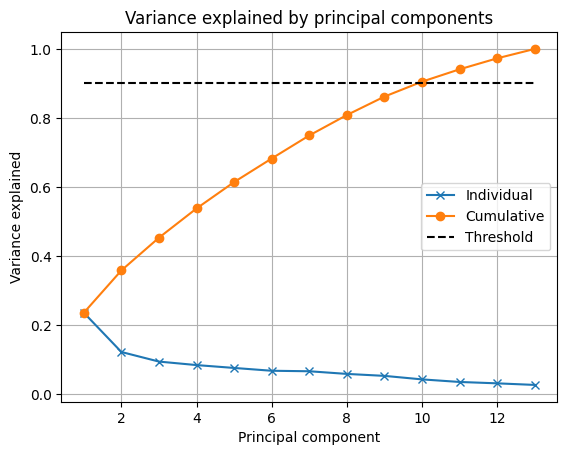

In [40]:
# Plot graf over, hvor mange komponenter der skal bruges for at forklare 95% af variansen
threshold = 0.90

# Plot variance explained
plt.figure()
plt.plot(range(1, len(rho) + 1), rho, "x-")
plt.plot(range(1, len(rho) + 1), np.cumsum(rho), "o-")
plt.plot([1, len(rho)], [threshold, threshold], "k--")
plt.title("Variance explained by principal components")
plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.legend(["Individual", "Cumulative", "Threshold"])
plt.grid()
plt.show()

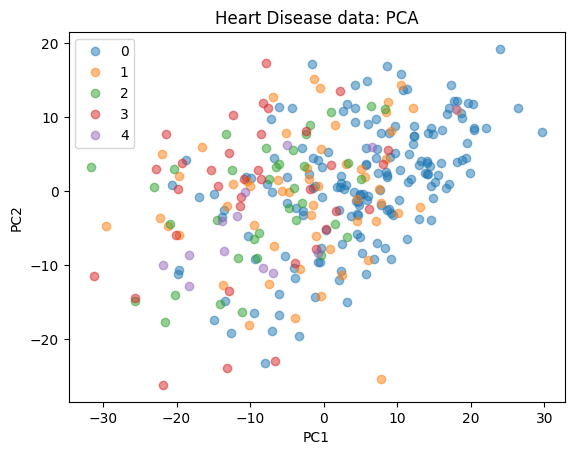

In [41]:
Y = df['num'].to_numpy()

V = Vh.T

Z = X_ @ V

classNames = [0,1,2,3,4]

C = len(classNames)
# Indices of the principal components to be plotted
i = 0
j = 1

# Plot PCA of the data
f = plt.figure()
plt.title("Heart Disease data: PCA")
# Z = array(Z)
for c in range(C):
    # select indices belonging to class c:
    class_mask = Y == c
    plt.plot(Z[class_mask, i], Z[class_mask, j], "o", alpha=0.5)
plt.legend(classNames)
plt.xlabel("PC{0}".format(i + 1))
plt.ylabel("PC{0}".format(j + 1))

# Output result to screen
plt.show()

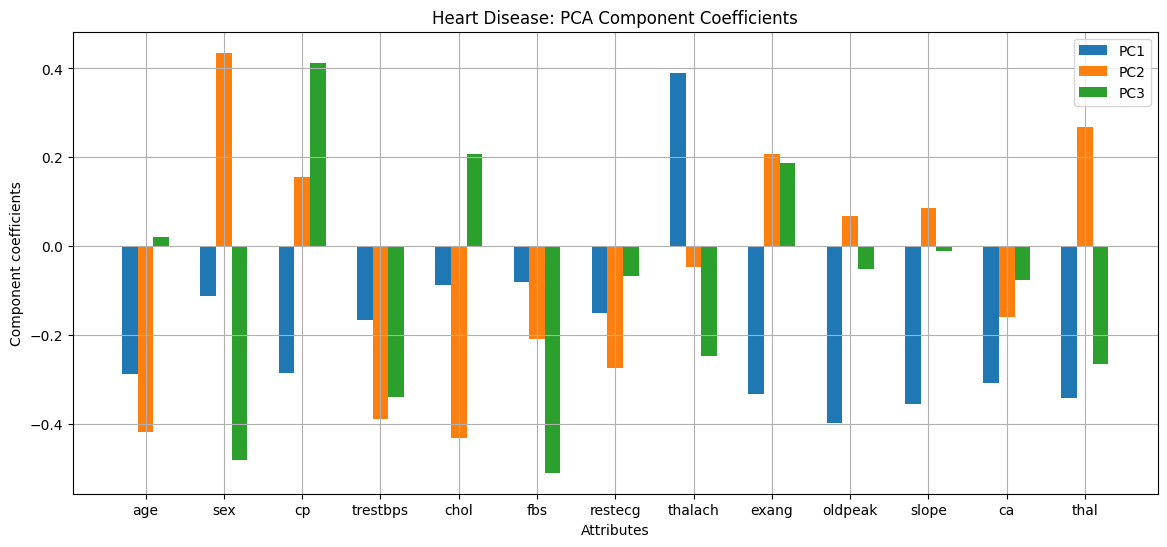

PC1:
[-0.28740153 -0.11257279 -0.28446719 -0.16659263 -0.08838921 -0.07999903
 -0.15085373  0.38940676 -0.33330751 -0.39787699 -0.35493142 -0.30861754
 -0.34179669]
PC2:
[-0.41877542  0.43545303  0.15509513 -0.3883917  -0.43204217 -0.20828764
 -0.27446213 -0.04788249  0.20826705  0.06883181  0.08584607 -0.15935295
  0.26751249]
PC3:
[ 0.02127358 -0.4811024   0.41172958 -0.34029914  0.20793048 -0.50982725
 -0.06760674 -0.24663393  0.1876091  -0.05045224 -0.01140766 -0.07593718
 -0.26564279]
Severe heart disease
[ 0.61626989  0.68620244  0.87798549 -0.0961698  -0.78527674 -0.41763453
  1.01668424 -0.77098952  1.43548113  1.17360762  0.64911323  1.43287667
  1.16731868]


In [55]:
N, M = X.shape

# Lad os se på koefficienterne for de tre første Principal components
pcs = [0, 1, 2]
legendStrs = ["PC" + str(e + 1) for e in pcs]
bw = 0.2
r = np.arange(1, M+1)

plt.figure(figsize=(14, 6))
for i in pcs:
    plt.bar(r + i * bw, V[:, i], width=bw)

plt.xticks(r + bw, attributeNames[:-1])
plt.xlabel("Attributes")
plt.ylabel("Component coefficients")
plt.legend(legendStrs)
plt.grid()
plt.title("Heart Disease: PCA Component Coefficients")

plt.show()

# Inspecting the plot, we see that the 2nd principal component has large
# (in magnitude) coefficients for attributes A, E and H. We can confirm
# this by looking at it's numerical values directly, too:

print("PC1:")
print(V[:, 0].T)

print("PC2:")
print(V[:, 1].T)

print("PC3:")
print(V[:, 2].T)

# How does this translate to the actual data and its projections?
# Looking at the data for water:

# Projection of all 4-degree heart diseases onto the 2nd principal component.
severe_heart_disease = X_hat[Y == 4, :]

print("Severe heart disease")
print(severe_heart_disease[0, :])

# Based on the coefficients and the attribute values for the observation
# displayed, would you expect the projection onto PC2 to be positive or
# negative - why? Consider *both* the magnitude and sign of *both* the
# coefficient and the attribute!

# You can determine the projection by (remove comments):
# print("...and its projection onto PC2") 
# print(all_water_data[0, :] @ V[:, 1])  
